In [69]:
#read data
import pandas as pd
import os
path = os.path.join(os.curdir, "iris.xlsx")
df = pd.read_excel(path)

print(df.head(),"\n")

#extract data
feature_cols = ["sepal length (cm)", "sepal width (cm)", "petal length (cm)", "petal width (cm)"] #interested features, no unammed: 5
x = df[feature_cols]   # features
y = df["target.1"]    # target/classes

print("size of features is:", x.shape,"\n", "n of examples is:", y.size)

#preprocecing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_train, x_test, y_train, y_test = train_test_split(
    x, y, 
    test_size=0.25, 
    #random_state=67, 
    stratify=y #dont create unbalaced rapp of classes
)

Std=StandardScaler()

#this is real standarization
std_x_train = Std.fit_transform(x_train)

#i use params of train standarization
std_x_test = Std.transform(x_test)

#cell1 preproc 
#2 trees
#3 nn
#confrontation

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

        target  Unnamed: 5  target.1  
0  Iris-setosa         NaN         0  
1  Iris-setosa         NaN         0  
2  Iris-setosa         NaN         0  
3  Iris-setosa         NaN         0  
4  Iris-setosa         NaN         0   

size of features is: (150, 4) 
 n of examples is: 150


In [70]:
#RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import pandas as pd

ntrees = 1 #it's too easy... 1 tree or 1000 trees dont change

# 1. Inizializzazione e Addestramento
forest = RandomForestClassifier(n_estimators=ntrees, random_state=67)
forest.fit(std_x_train, y_train)

# 2. Predizione
y_pred_forest = forest.predict(std_x_test)

# 3. Valutazione: Matrice di Confusione
confusion_matrix_forest = pd.DataFrame(
    confusion_matrix(y_test, y_pred_forest),
    index=forest.classes_,
    columns=forest.classes_
)
print(f"Confusion Matrix for Random Forest ({ntrees} alberi):\n", confusion_matrix_forest)

# 4. Valutazione: Accuratezza
good_percentage = accuracy_score(y_test, y_pred_forest) * 100
print(f"\nPercentage of good predictions for Random Forest: {good_percentage:.2f}%\n")

# 5. Valutazione: Precision, Recall e F1-score
print("Report di Classificazione (Precision, Recall, F1-score):")
print(classification_report(y_test, y_pred_forest))


Confusion Matrix for Random Forest (1 alberi):
     0   1   2
0  13   0   0
1   0  12   1
2   0   2  10

Percentage of good predictions for Random Forest: 92.11%

Report di Classificazione (Precision, Recall, F1-score):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.86      0.92      0.89        13
           2       0.91      0.83      0.87        12

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



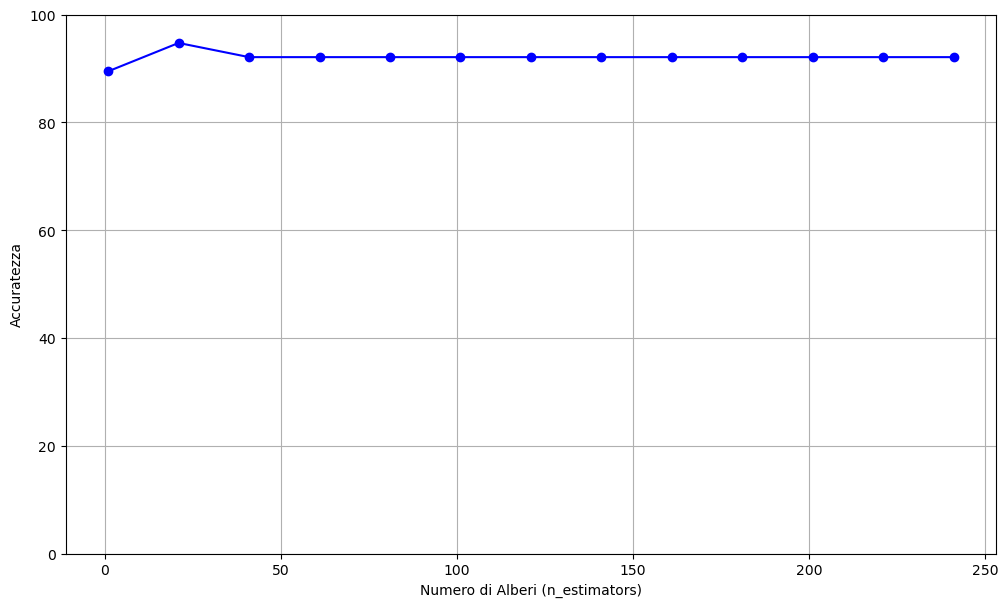

In [ ]:
#performance of trees
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# function to create and rate lots of forest
def doRandomForest(ntrees, x_train, y_train, x_test, y_test):
    """
    Crea una Random Forest con 'numero_alberi', la addestra e
    restituisce sia l'accuratezza sia la confusion matrix sul test set.
    """
    forest = RandomForestClassifier(n_estimators=ntrees)
    forest.fit(x_train, y_train)
    y_pred = forest.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)
    confusion_matrix_forest = pd.DataFrame(
        confusion_matrix(y_test, y_pred),
        index=forest.classes_,
        columns=forest.classes_
    )
    return accuracy, confusion_matrix_forest


ntrees_list  = range(1, 251, 20)
risultati_accuratezza = []
risultati_confusion_matrix = []

#create and testin forest
for n in ntrees_list:
    acc, cm = doRandomForest(n, std_x_train, y_train, std_x_test, y_test)
    risultati_accuratezza.append(acc * 100) #from 0-1 to 0 and 100
    risultati_confusion_matrix.append(cm)

#plotting acc
plt.figure(figsize=(12, 7))
plt.plot(ntrees_list, risultati_accuratezza, marker='o', linestyle='-', color='b')
plt.xlabel("Numero di Alberi (n_estimators)")
plt.ylabel("Accuratezza")
plt.grid(True)
plt.ylim(0, 100)
plt.show()
